In [1]:
#Load libs

from io import open
import os, string, random, time, math, zipfile, csv, io, pickle, hashlib
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import clear_output

import warnings
warnings.filterwarnings("ignore")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
#Dataset - load first names and last names from name_dataset.zip (with pickle cache)

MAX_PER_COUNTRY = 50000
CACHE_SCHEMA_VERSION = 1  # bump this if the loading/filtering logic below changes

CACHE_PATH = f'name_dataset_cache_{MAX_PER_COUNTRY}.pkl'
ZIP_PATH = '../../../../data/final_project/qicheng-lee/raw/name_dataset.zip'

def _zip_provenance():
    # Fingerprints the raw zip (size + mtime) plus the params/logic version that
    # produced the cache, so a stale or swapped-out zip can't silently keep serving
    # old cached data.
    stat = os.stat(ZIP_PATH)
    fingerprint = f"{stat.st_size}|{int(stat.st_mtime)}|{MAX_PER_COUNTRY}|schema={CACHE_SCHEMA_VERSION}"
    return hashlib.md5(fingerprint.encode()).hexdigest()

current_provenance = _zip_provenance()

cache_valid = False
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'rb') as f:
        cached = pickle.load(f)
    if cached.get('provenance') == current_provenance:
        cache_valid = True
        nationalities = cached['nationalities']
        X_first = cached['X_first']
        X_last = cached['X_last']
        y_first = cached['y_first']
        y_last = cached['y_last']
        print(f"Loaded from cache: {len(X_first)} names across {len(nationalities)} nationalities")
    else:
        print("Cache is stale (raw zip or loading logic changed since cache was built) - rebuilding.")

if not cache_valid:
    nationalities = []
    X_first = []
    X_last = []
    y_first = []
    y_last = []

    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        total_rows = 0
        for csv_file in tqdm(csv_files, desc="Loading countries"):
            country_code = csv_file.split('/')[-1].replace('.csv', '')
            with z.open(csv_file) as f:
                reader = csv.reader(io.TextIOWrapper(f, encoding='utf-8'))
                rows = [row for row in reader if len(row) >= 4]
            if len(rows) > MAX_PER_COUNTRY:
                rows = random.sample(rows, MAX_PER_COUNTRY)
            for row in rows:
                first_name = row[0].strip()
                last_name = row[1].strip()
                nationality = row[3].strip()
                if not first_name or not last_name:
                    continue
                if nationality not in nationalities:
                    nationalities.append(nationality)
                X_first.append(first_name)
                y_first.append(nationality)
                X_last.append(last_name)
                y_last.append(nationality)
                total_rows += 1

    with open(CACHE_PATH, 'wb') as f:
        pickle.dump({
            'provenance': current_provenance,
            'nationalities': nationalities,
            'X_first': X_first, 'X_last': X_last,
            'y_first': y_first, 'y_last': y_last,
        }, f)
    print(f"Loaded from zip and cached: {total_rows:,} names across {len(nationalities)} nationalities")

n_nationalities = len(nationalities)

Cache is stale (raw zip or loading logic changed since cache was built) - rebuilding.


Loading countries:   0%|          | 0/105 [00:00<?, ?it/s]

Loaded from zip and cached: 4,734,020 names across 105 nationalities


In [3]:
# Merge nationalities into ~23 distinctive groups and drop ambiguous ones

NATIONALITY_MAP = {
    # Tier 1 - Highly distinctive (keep as-is)
    'JP': 'JP',  # Japanese
    'KR': 'KR',  # Korean
    'CN': 'CN',  # Chinese
    'FI': 'FI',  # Finnish
    'GE': 'GE',  # Georgian
    'GR': 'GR',  # Greek
    'HU': 'HU',  # Hungarian
    'IS': 'IS',  # Icelandic

    # Tier 2 - Distinctive (keep as-is)
    'PL': 'PL',  # Polish
    'IT': 'IT',  # Italian
    'FR': 'FR',  # French
    'TR': 'TR',  # Turkish
    'IR': 'IR',  # Persian
    'LT': 'LT',  # Lithuanian
    'IN': 'IN',  # Indian
    'NG': 'NG',  # Nigerian

    # Tier 3 - Merged groups
    # Chinese-script regions → CN
    'TW': 'CN', 'HK': 'CN', 'MO': 'CN',

    # Spanish-speaking → ES
    'ES': 'ES', 'MX': 'ES', 'CR': 'ES', 'UY': 'ES', 'PE': 'ES',
    'PR': 'ES', 'PA': 'ES', 'EC': 'ES', 'SV': 'ES', 'GT': 'ES',
    'HN': 'ES', 'CL': 'ES', 'AR': 'ES', 'CO': 'ES', 'BO': 'ES',

    # Portuguese-speaking → PT
    'PT': 'PT', 'BR': 'PT', 'AO': 'PT',

    # Arabic-speaking → SA
    'SA': 'SA', 'TN': 'SA', 'LY': 'SA', 'EG': 'SA', 'IQ': 'SA',
    'PS': 'SA', 'QA': 'SA', 'JO': 'SA', 'SY': 'SA', 'KW': 'SA',
    'BH': 'SA', 'AE': 'SA', 'OM': 'SA', 'YE': 'SA', 'LB': 'SA',
    'DZ': 'SA', 'MA': 'SA', 'SD': 'SA', 'DJ': 'SA',

    # English-speaking → GB
    'GB': 'GB', 'US': 'GB', 'CA': 'GB', 'IE': 'GB', 'JM': 'GB',

    # Nordic → SE
    'SE': 'SE', 'DK': 'SE', 'NO': 'SE',

    # Germanic (German + Dutch) → GM
    'DE': 'GM', 'NL': 'GM',

    # Slavic (including Russian) → CZ
    'CZ': 'CZ', 'HR': 'CZ', 'RS': 'CZ', 'SI': 'CZ', 'BG': 'CZ',
    'RU': 'CZ',

    # Turkic → TR
    'AZ': 'TR', 'TM': 'TR', 'KZ': 'TR',

    # French-influenced African → FR
    'HT': 'FR', 'CM': 'FR',

    # Persian-adjacent → IR
    'AF': 'IR',

    # West African → NG
    'GH': 'NG', 'BF': 'NG',

    # Greek-adjacent → GR
    'CY': 'GR',

    # Ethiopian — dropped (too few samples, 0% recall)
    # 'ET': dropped
}

original_nats = set(nationalities)

def apply_nationality_filter(X, y):
    X_filtered, y_filtered = [], []
    for name, nat in zip(X, y):
        if nat in NATIONALITY_MAP:
            X_filtered.append(name)
            y_filtered.append(NATIONALITY_MAP[nat])
    return X_filtered, y_filtered

X_first, y_first = apply_nationality_filter(X_first, y_first)
X_last, y_last = apply_nationality_filter(X_last, y_last)

nationalities = sorted(set(NATIONALITY_MAP.values()))
n_nationalities = len(nationalities)

dropped = original_nats - set(NATIONALITY_MAP.keys())
print(f"Filtered to {n_nationalities} nationalities: {nationalities}")
print(f"Total first names: {len(X_first):,} | Total last names: {len(X_last):,}")
if dropped:
    print(f"Dropped (too mixed/ambiguous): {sorted(dropped)}")

Filtered to 23 nationalities: ['CN', 'CZ', 'ES', 'FI', 'FR', 'GB', 'GE', 'GM', 'GR', 'HU', 'IN', 'IR', 'IS', 'IT', 'JP', 'KR', 'LT', 'NG', 'PL', 'PT', 'SA', 'SE', 'TR']
Total first names: 3,706,913 | Total last names: 3,706,913
Dropped (too mixed/ambiguous): ['AL', 'AT', 'BD', 'BE', 'BI', 'BN', 'BW', 'CH', 'EE', 'ET', 'FJ', 'ID', 'IL', 'KH', 'LU', 'MD', 'MT', 'MU', 'MV', 'MY', 'NA', 'PH', 'SG', 'ZA']


In [4]:
COUNTRY_NAMES = {
    'CN': 'Chinese',
    'CZ': 'Slavic',
    'ES': 'Spanish',
    'FI': 'Finnish',
    'FR': 'French',
    'GB': 'English',
    'GE': 'Georgian',
    'GM': 'Germanic',
    'GR': 'Greek',
    'HU': 'Hungarian',
    'IN': 'Indian',
    'IR': 'Persian',
    'IS': 'Icelandic',
    'IT': 'Italian',
    'JP': 'Japanese',
    'KR': 'Korean',
    'LT': 'Lithuanian',
    'NG': 'Nigerian',
    'PL': 'Polish',
    'PT': 'Portuguese',
    'SA': 'Arabic',
    'SE': 'Nordic',
    'TR': 'Turkish',
}

nat_names = [COUNTRY_NAMES[n] for n in nationalities]
print(f"{len(nationalities)} nationalities:")
for code in nationalities:
    print(f"  {code} = {COUNTRY_NAMES[code]}")

23 nationalities:
  CN = Chinese
  CZ = Slavic
  ES = Spanish
  FI = Finnish
  FR = French
  GB = English
  GE = Georgian
  GM = Germanic
  GR = Greek
  HU = Hungarian
  IN = Indian
  IR = Persian
  IS = Icelandic
  IT = Italian
  JP = Japanese
  KR = Korean
  LT = Lithuanian
  NG = Nigerian
  PL = Polish
  PT = Portuguese
  SA = Arabic
  SE = Nordic
  TR = Turkish


In [5]:
#Encoding names and nationalities

all_letters = string.ascii_letters + " .,;'-" + "àáâãäåæçèéêëìíîïðñòóôõöøùúûüýþÿÀÁÂÃÄÅÆÇÈÉÊËÌÍÎÏÐÑÒÓÔÕÖØÙÚÛÜÝÞ"
n_letters = len(all_letters)

print(n_letters)
print(all_letters)

119
abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ .,;'-àáâãäåæçèéêëìíîïðñòóôõöøùúûüýþÿÀÁÂÃÄÅÆÇÈÉÊËÌÍÎÏÐÑÒÓÔÕÖØÙÚÛÜÝÞ


In [6]:
def name_rep(name):
    rep = torch.zeros(len(name), 1, n_letters)
    for index, letter in enumerate(name):
        pos = all_letters.find(letter)
        if pos >= 0:
            rep[index][0][pos] = 1
    return rep

In [7]:
def nat_rep(nat):
    return torch.tensor([nationalities.index(nat)], dtype=torch.long)

In [8]:
name_rep('Smith')

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [9]:
nat_rep(nationalities[0])

tensor([0])

In [10]:
#Model definitions

class RNN_net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN_net, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input_, hidden):     
        combined = torch.cat((input_, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output = self.softmax(output)
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

In [11]:
#LSTM cell

class LSTM_net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM_net, self).__init__()
        self.hidden_size = hidden_size
        self.lstm_cell = nn.LSTM(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=2)
    
    def forward(self, input_, hidden):
        out, hidden = self.lstm_cell(input_.view(1, 1, -1), hidden)
        output = self.h2o(hidden[0])
        output = self.softmax(output)
        return output.view(1, -1), hidden
    
    def init_hidden(self):
        return (torch.zeros(1, 1, self.hidden_size), torch.zeros(1, 1, self.hidden_size))

In [12]:
#GRU cell

class GRU_net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.3):
        super(GRU_net, self).__init__()
        self.hidden_size = hidden_size
        self.gru_cell = nn.GRU(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=2)
    
    def forward(self, input_, hidden):
        out, hidden = self.gru_cell(input_.view(1, 1, -1), hidden)
        output = self.dropout(hidden)
        output = self.h2o(output)
        output = self.softmax(output)
        return output.view(1, -1), hidden
    
    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size)

#Bidirectional GRU

class BiGRU_net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BiGRU_net, self).__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.h2o = nn.Linear(hidden_size * 2, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward_full(self, input_seq):
        x = input_seq.squeeze(1).unsqueeze(0)
        _, hidden = self.gru(x)
        hidden_cat = torch.cat((hidden[0], hidden[1]), dim=1)
        output = self.softmax(self.h2o(hidden_cat))
        return output

    def forward(self, input_, hidden):
        out, hidden = self.gru(input_.view(1, 1, -1), hidden)
        hidden_fwd = hidden[0:1]
        output = self.h2o(torch.cat((hidden_fwd, hidden_fwd), dim=2).squeeze(0))
        output = self.softmax(output.unsqueeze(0))
        return output.view(1, -1), hidden

    def init_hidden(self):
        return torch.zeros(2, 1, self.hidden_size)

In [13]:
#Helper functions

def infer(net, name):
    net.eval()
    name_ohe = name_rep(name)
    hidden = net.init_hidden()
    
    if name_ohe.size()[0] == 0:
        return None
    
    for i in range(name_ohe.size()[0]):
        output, hidden = net(name_ohe[i], hidden)
    
    return output

def dataloader(npoints, X_, y_, replace=True):
    to_ret = []
    if replace:
        indices = np.random.randint(len(X_), size=npoints)
    else:
        indices = np.random.permutation(len(X_))[:npoints]
    for index_ in indices:
        name, nat = X_[index_], y_[index_]
        to_ret.append((name, nat, name_rep(name), nat_rep(nat)))
    return to_ret

def eval_model(net, n_points, k, X_, y_, desc=None):
    
    data_ = dataloader(n_points, X_, y_, replace=False)
    correct = 0
    
    iterator = tqdm(data_, desc=desc or f"Eval (top-{k})", leave=False) if n_points >= 5000 else data_
    
    for name, nationality, name_ohe, nat_rep in iterator:
        
        output = infer(net, name)
        if output is None:
            continue
        val, indices = output.topk(k)
        
        if nat_rep in indices:
            correct += 1
            
    accuracy = correct/n_points
    return accuracy

def eval_confusion(net, n_points, X_, y_):
    data_ = dataloader(n_points, X_, y_, replace=False)
    y_true, y_pred = [], []
    for name, nationality, name_ohe, nat_idx in tqdm(data_, desc="Eval confusion matrix", leave=False):
        output = infer(net, name)
        if output is None:
            continue
        pred_idx = output.argmax(dim=1).item()
        y_true.append(nat_idx.item())
        y_pred.append(pred_idx)
    print(classification_report(y_true, y_pred, target_names=nat_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=nat_names, yticklabels=nat_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def train_one(net, opt, criterion, n_points, X_train, y_train):
    
    net.train()
    total_loss = 0
    
    data_ = dataloader(n_points, X_train, y_train)
    
    for name, nationality, name_ohe, nat_rep in data_:

        hidden = net.init_hidden()

        if name_ohe.size()[0] == 0:
            continue

        opt.zero_grad()

        for i in range(name_ohe.size()[0]):
            output, hidden = net(name_ohe[i], hidden)
            
        loss = criterion(output, nat_rep)
        loss.backward()
        
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=5)
        opt.step()
        
        total_loss += loss.item()
            
    return total_loss/n_points

def train_setup(net, X_train, y_train, X_test, y_test, lr=0.01, n_batches=100, batch_size=10, display_freq=50, class_weights=None, patience=10):
    
    criterion = nn.NLLLoss(weight=class_weights)
    opt = optim.Adam(net.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    
    loss_arr = np.zeros(n_batches + 1)
    
    best_top1 = 0.0
    best_state = None
    wait = 0
    stopped_at = n_batches
    
    pbar = tqdm(range(n_batches), desc="Training")
    for i in pbar:
        loss_arr[i+1] = (loss_arr[i]*i + train_one(net, opt, criterion, batch_size, X_train, y_train))/(i + 1)
        pbar.set_postfix(loss=f"{loss_arr[i+1]:.4f}")
        
        if i%display_freq == display_freq-1:
            top1 = eval_model(net, 1000, 1, X_test, y_test, desc="Eval top-1")
            top2 = eval_model(net, 1000, 2, X_test, y_test, desc="Eval top-2")
            current_lr = opt.param_groups[0]['lr']
            pbar.set_postfix(loss=f"{loss_arr[i+1]:.4f}", top1=f"{top1:.4f}", top2=f"{top2:.4f}", lr=f"{current_lr:.6f}")
            
            scheduler.step(top1)
            
            if top1 > best_top1:
                best_top1 = top1
                best_state = copy.deepcopy(net.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"\nEarly stopping at iteration {i+1} (no improvement for {patience} evals). Best top-1: {best_top1:.4f}")
                    stopped_at = i + 1
                    break
    
    if best_state is not None:
        net.load_state_dict(best_state)
        print(f"Restored best model (top-1: {best_top1:.4f})")
    
    plt.figure()
    plt.plot(loss_arr[1:stopped_at+1], '-*')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.show()
    
    top1 = eval_model(net, len(X_test), 1, X_test, y_test, desc="Final eval top-1")
    top2 = eval_model(net, len(X_test), 2, X_test, y_test, desc="Final eval top-2")
    print(f'Final | Top-1: {top1:.4f} | Top-2: {top2:.4f} | Loss: {loss_arr[stopped_at]:.4f}')

def predict(net, name, n_top=3):
    output = infer(net, name)
    topv, topi = output.topk(n_top)
    results = []
    for i in range(n_top):
        prob = math.exp(topv[0][i].item())
        nat = nationalities[topi[0][i].item()]
        results.append((nat, prob))
        print(f"{COUNTRY_NAMES[nat]} ({nat}): {prob:.4f}")
    return results

def predict_full_name(net_first, net_last, first_name, last_name, n_top=3):
    out_first = infer(net_first, first_name)
    out_last = infer(net_last, last_name)
    if out_first is None or out_last is None:
        return []
    combined = (out_first + out_last) / 2
    topv, topi = combined.topk(n_top)
    results = []
    for i in range(n_top):
        prob = math.exp(topv[0][i].item())
        nat = nationalities[topi[0][i].item()]
        results.append((nat, prob))
        print(f"{COUNTRY_NAMES[nat]} ({nat}): {prob:.4f}")
    return results

---
# Last Name Model

In [14]:
#Train-test split (last names)

X_train, X_test, y_train, y_test = train_test_split(X_last, y_last, test_size=0.2, random_state=0, stratify=y_last)

print(len(X_train), len(X_test))

2965530 741383


In [15]:
#Basic visualisation (last names)

count = {}
for n in nationalities: 
    count[n] = 0
for nat in y_last:
    count[nat] += 1

print(count)

{'CN': 159273, 'CZ': 298986, 'ES': 667249, 'FI': 49962, 'FR': 115312, 'GB': 249086, 'GE': 49916, 'GM': 99751, 'GR': 99589, 'HU': 49940, 'IN': 49333, 'IR': 99856, 'IS': 31230, 'IT': 49892, 'JP': 48641, 'KR': 8380, 'LT': 49929, 'NG': 106206, 'PL': 49948, 'PT': 149692, 'SA': 909024, 'SE': 149639, 'TR': 166079}


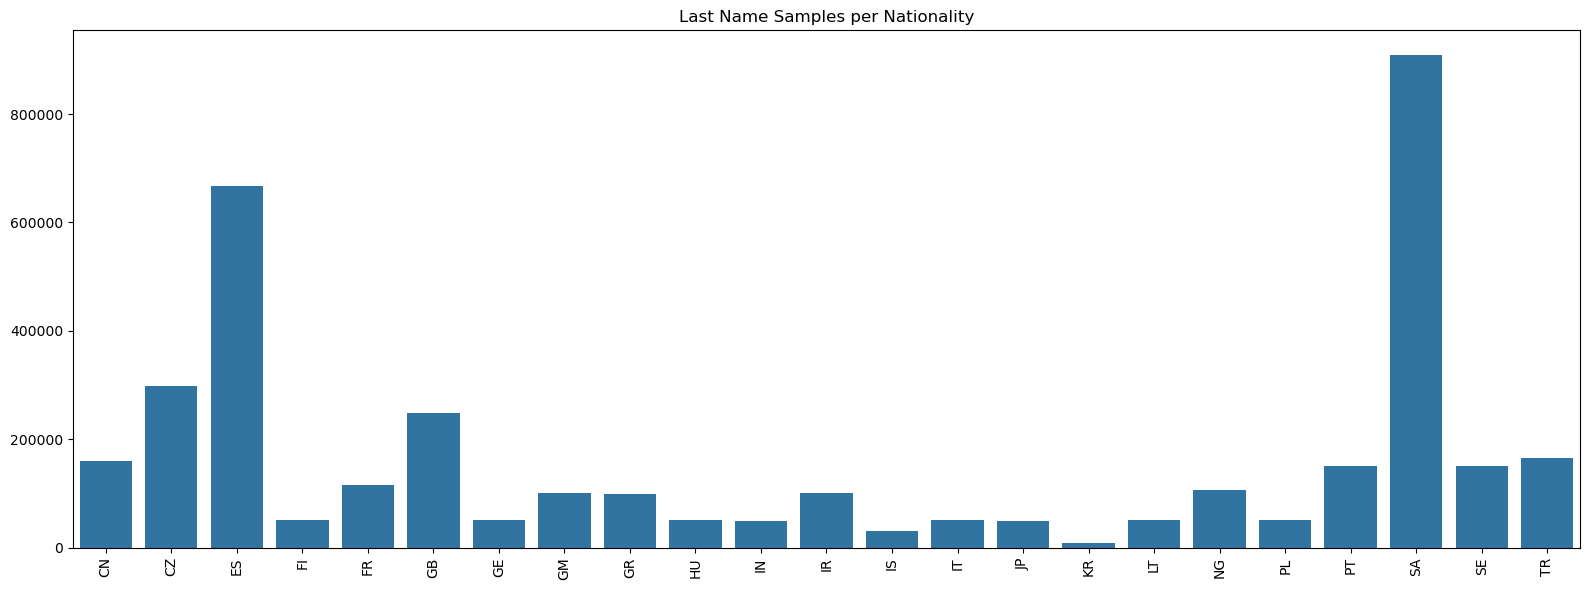

In [16]:
plt.figure(figsize=(16, 6))
plt_ = sns.barplot(x=list(count.keys()), y=list(count.values()))
plt_.set_xticklabels(plt_.get_xticklabels(), rotation=90)
plt.title('Last Name Samples per Nationality')
plt.tight_layout()
plt.show()

In [17]:
n_hidden = 128
net_last = RNN_net(n_letters, n_hidden, n_nationalities)

In [18]:
output = infer(net_last, 'Kim')
index = torch.argmax(output)
print(output, index)

tensor([[-3.0457, -3.0829, -3.1625, -3.1505, -3.1131, -3.1484, -3.1109, -3.1399,
         -3.2503, -3.1372, -3.1093, -3.1887, -3.1808, -3.0237, -3.1088, -3.1980,
         -3.1771, -3.1270, -3.1456, -3.1549, -3.0894, -3.1359, -3.1630]],
       grad_fn=<LogSoftmaxBackward0>) tensor(13)


In [19]:
eval_model(net_last, 1000, 3, X_test, y_test)

0.122

In [20]:
criterion = nn.NLLLoss()
opt = optim.SGD(net_last.parameters(), lr=0.01, momentum=0.9)

In [21]:
%%time 
train_one(net_last, opt, criterion, 200, X_train, y_train)

CPU times: total: 203 ms
Wall time: 224 ms


2.741362642943859

In [22]:
eval_model(net_last, 1000, 1, X_test, y_test)

0.29

In [23]:
total_samples = sum(count.values())
class_weights = torch.tensor([total_samples / count[nat] for nat in nationalities], dtype=torch.float)
class_weights = class_weights / class_weights.median()
print("Class weights (last name):")
for nat, w in zip(nationalities, class_weights):
    print(f"  {nat}: {w:.4f}")

Class weights (last name):
  CN: 0.6263
  CZ: 0.3336
  ES: 0.1495
  FI: 1.9965
  FR: 0.8651
  GB: 0.4005
  GE: 1.9984
  GM: 1.0000
  GR: 1.0016
  HU: 1.9974
  IN: 2.0220
  IR: 0.9989
  IS: 3.1941
  IT: 1.9993
  JP: 2.0508
  KR: 11.9035
  LT: 1.9979
  NG: 0.9392
  PL: 1.9971
  PT: 0.6664
  SA: 0.1097
  SE: 0.6666
  TR: 0.6006


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Restored best model (top-1: 0.6010)


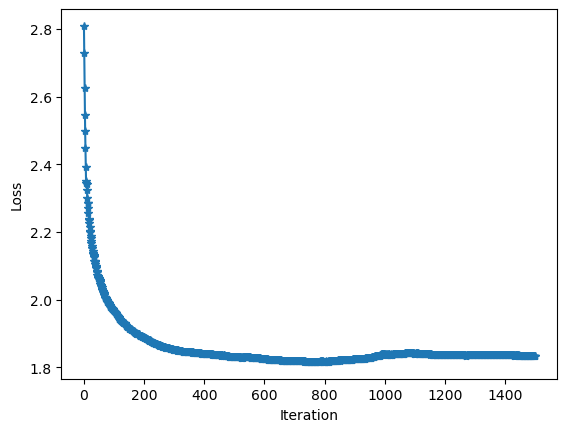

Final eval top-1:   0%|          | 0/741383 [00:00<?, ?it/s]

Final eval top-2:   0%|          | 0/741383 [00:00<?, ?it/s]

Final | Top-1: 0.5770 | Top-2: 0.7030 | Loss: 1.8326


In [24]:
#Reseed right before building/training the real model - this makes its initial
#weights (and therefore the trained result) independent of how many random draws
#the exploration cells above consumed.
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

n_hidden = 256
net_last = GRU_net(n_letters, n_hidden, n_nationalities)
train_setup(net_last, X_train, y_train, X_test, y_test, lr=0.005, n_batches=1500, batch_size=256, class_weights=class_weights)

Eval confusion matrix:   0%|          | 0/5000 [00:00<?, ?it/s]

              precision    recall  f1-score   support

     Chinese       0.65      0.64      0.64       220
      Slavic       0.52      0.64      0.57       422
     Spanish       0.67      0.81      0.73       859
     Finnish       0.90      0.35      0.50        77
      French       0.43      0.13      0.20       143
     English       0.42      0.49      0.45       341
    Georgian       0.88      0.35      0.51        62
    Germanic       0.59      0.28      0.38       139
       Greek       0.52      0.34      0.41       127
   Hungarian       0.69      0.42      0.52        64
      Indian       0.00      0.00      0.00        67
     Persian       0.55      0.09      0.15       137
   Icelandic       0.75      0.64      0.69        33
     Italian       0.45      0.23      0.31        56
    Japanese       0.72      0.21      0.32        63
      Korean       0.50      0.07      0.12        15
  Lithuanian       0.81      0.56      0.66        61
    Nigerian       0.61    

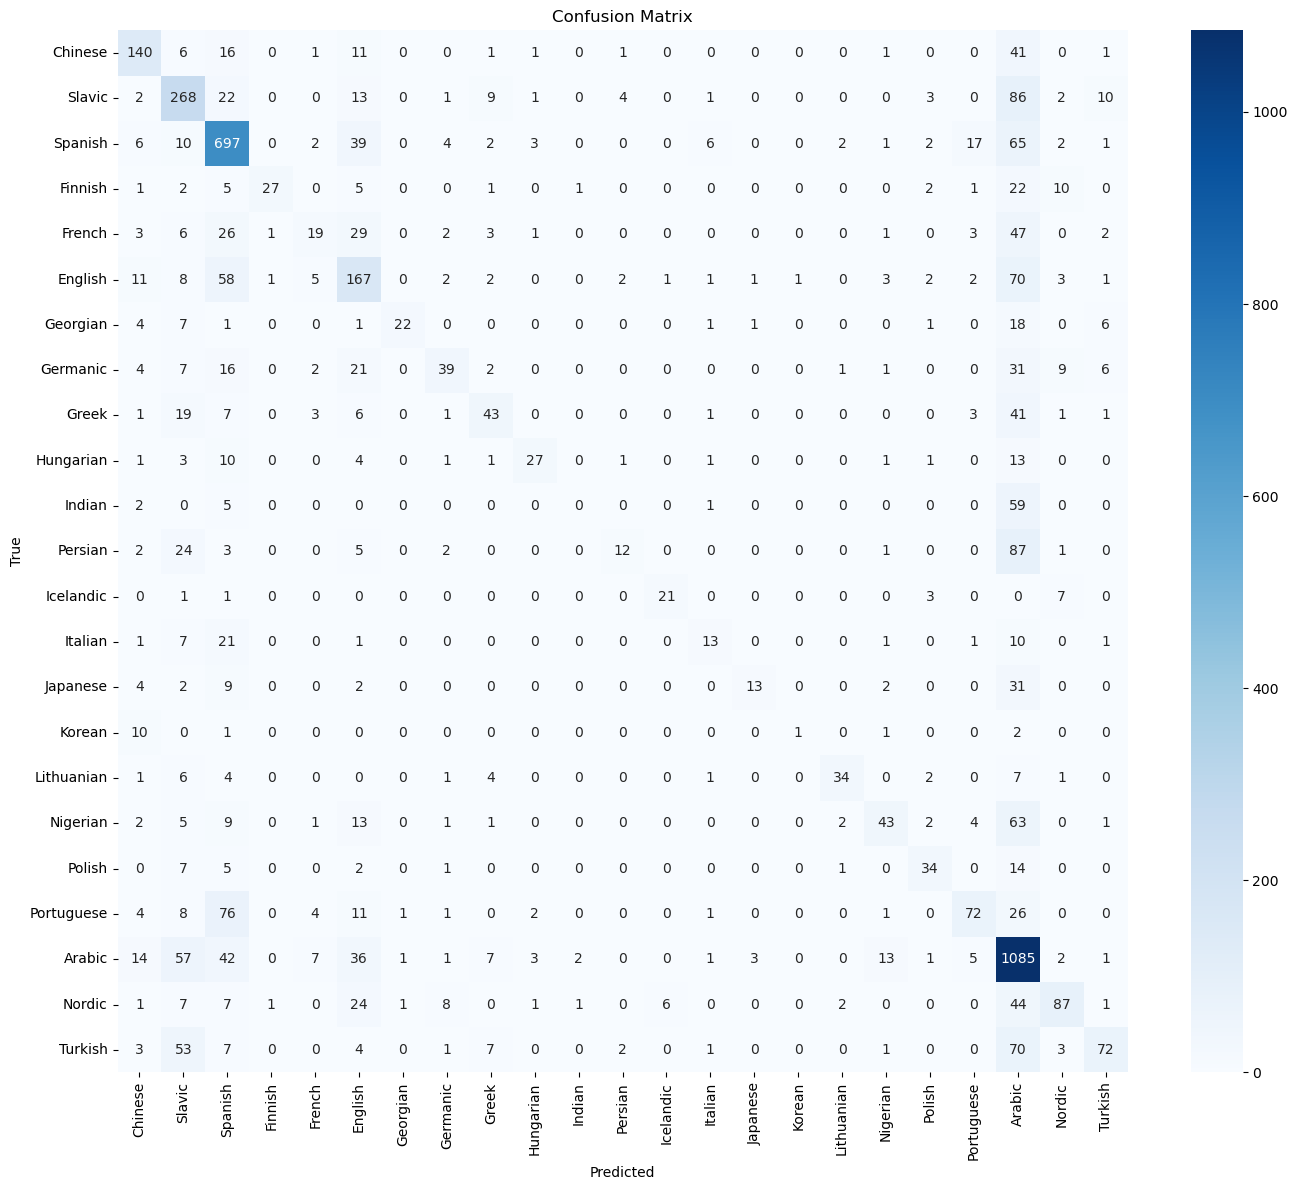

In [25]:
# Per-nationality evaluation (last name model)
eval_confusion(net_last, 5000, X_test, y_test)

In [26]:
# Confidence vs accuracy analysis (last name model)
data_ = dataloader(10000, X_test, y_test, replace=False)
buckets = {}
for name, nat, name_ohe, nat_idx in data_:
    output = infer(net_last, name)
    if output is None:
        continue
    topv, topi = output.topk(1)
    conf = math.exp(topv[0][0].item())
    bucket = round(conf, 1)
    correct = (topi[0][0].item() == nat_idx.item())
    buckets.setdefault(bucket, [0, 0])
    buckets[bucket][0] += correct
    buckets[bucket][1] += 1

print("Confidence | Accuracy | Count")
for b in sorted(buckets):
    acc = buckets[b][0] / buckets[b][1]
    print(f"     {b:.1f}    |  {acc:.2f}    | {buckets[b][1]}")

Confidence | Accuracy | Count
     0.1    |  0.10    | 69
     0.2    |  0.25    | 1304
     0.3    |  0.33    | 1530
     0.4    |  0.48    | 1580
     0.5    |  0.59    | 900
     0.6    |  0.70    | 782
     0.7    |  0.74    | 918
     0.8    |  0.79    | 878
     0.9    |  0.86    | 880
     1.0    |  0.89    | 1159


In [27]:
print("--- Kim ---")
predict(net_last, "Kim")
print("\n--- Mueller ---")
predict(net_last, "Mueller")
print("\n--- Tanaka ---")
predict(net_last, "Tanaka")
print("\n--- Singh ---")
predict(net_last, "Singh")

--- Kim ---
Korean (KR): 0.4277
Arabic (SA): 0.2083
Chinese (CN): 0.0964

--- Mueller ---
English (GB): 0.3279
Spanish (ES): 0.1270
Germanic (GM): 0.1133

--- Tanaka ---
Japanese (JP): 0.3733
Arabic (SA): 0.1670
Slavic (CZ): 0.0816

--- Singh ---
Arabic (SA): 0.4053
Indian (IN): 0.2461
English (GB): 0.1726


[('SA', 0.4052535293931678),
 ('IN', 0.24608725968067616),
 ('GB', 0.17262658937127506)]

In [28]:
torch.save(net_last.state_dict(), 'rnn_lastname_nat.pth')
print("Last name model saved to rnn_lastname_nat.pth")

Last name model saved to rnn_lastname_nat.pth


In [29]:
# Load saved last name model (skip training cell above if already trained)
n_hidden = 256
net_last = GRU_net(n_letters, n_hidden, n_nationalities)
net_last.load_state_dict(torch.load('rnn_lastname_nat.pth', weights_only=True))
net_last.eval()
print("Last name model loaded from rnn_lastname_nat.pth")

Last name model loaded from rnn_lastname_nat.pth


---
# First Name Model

In [30]:
#Train-test split (first names)

X_train, X_test, y_train, y_test = train_test_split(X_first, y_first, test_size=0.2, random_state=0, stratify=y_first)

print(len(X_train), len(X_test))

2965530 741383


In [31]:
#Basic visualisation (first names)

count = {}
for n in nationalities: 
    count[n] = 0
for nat in y_first:
    count[nat] += 1

print(count)

{'CN': 159273, 'CZ': 298986, 'ES': 667249, 'FI': 49962, 'FR': 115312, 'GB': 249086, 'GE': 49916, 'GM': 99751, 'GR': 99589, 'HU': 49940, 'IN': 49333, 'IR': 99856, 'IS': 31230, 'IT': 49892, 'JP': 48641, 'KR': 8380, 'LT': 49929, 'NG': 106206, 'PL': 49948, 'PT': 149692, 'SA': 909024, 'SE': 149639, 'TR': 166079}


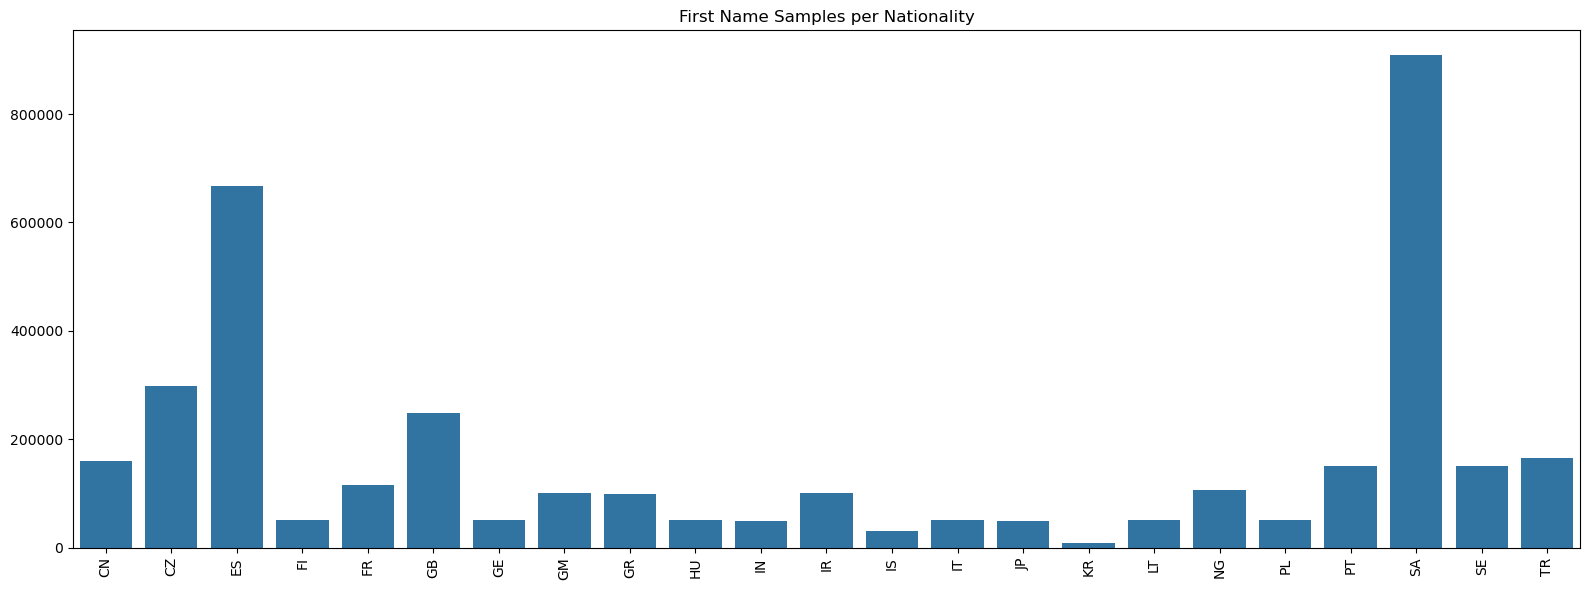

In [32]:
plt.figure(figsize=(16, 6))
plt_ = sns.barplot(x=list(count.keys()), y=list(count.values()))
plt_.set_xticklabels(plt_.get_xticklabels(), rotation=90)
plt.title('First Name Samples per Nationality')
plt.tight_layout()
plt.show()

In [33]:
n_hidden = 128
net_first = RNN_net(n_letters, n_hidden, n_nationalities)

In [34]:
output = infer(net_first, 'Giovanni')
index = torch.argmax(output)
print(output, index)

tensor([[-3.1775, -3.1114, -3.2111, -3.0794, -3.1068, -3.0850, -3.1537, -3.1589,
         -3.1517, -3.1334, -3.1089, -3.2140, -3.2215, -3.0649, -3.1972, -2.9949,
         -3.1922, -3.1040, -3.1429, -3.1261, -3.1060, -3.1710, -3.1366]],
       grad_fn=<LogSoftmaxBackward0>) tensor(15)


In [35]:
eval_model(net_first, 1000, 3, X_test, y_test)

0.107

In [36]:
criterion = nn.NLLLoss()
opt = optim.SGD(net_first.parameters(), lr=0.01, momentum=0.9)

In [37]:
%%time 
train_one(net_first, opt, criterion, 200, X_train, y_train)

CPU times: total: 203 ms
Wall time: 173 ms


2.814818594753742

In [38]:
eval_model(net_first, 1000, 1, X_test, y_test)

0.291

In [39]:
total_samples = sum(count.values())
class_weights = torch.tensor([total_samples / count[nat] for nat in nationalities], dtype=torch.float)
class_weights = class_weights / class_weights.median()
print("Class weights (first name):")
for nat, w in zip(nationalities, class_weights):
    print(f"  {nat}: {w:.4f}")

Class weights (first name):
  CN: 0.6263
  CZ: 0.3336
  ES: 0.1495
  FI: 1.9965
  FR: 0.8651
  GB: 0.4005
  GE: 1.9984
  GM: 1.0000
  GR: 1.0016
  HU: 1.9974
  IN: 2.0220
  IR: 0.9989
  IS: 3.1941
  IT: 1.9993
  JP: 2.0508
  KR: 11.9035
  LT: 1.9979
  NG: 0.9392
  PL: 1.9971
  PT: 0.6664
  SA: 0.1097
  SE: 0.6666
  TR: 0.6006


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Restored best model (top-1: 0.5170)


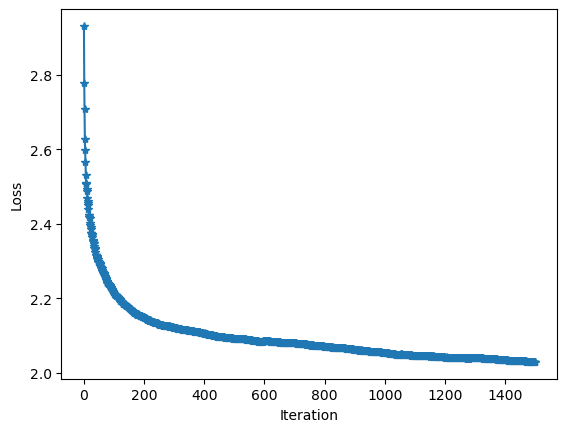

Final eval top-1:   0%|          | 0/741383 [00:00<?, ?it/s]

Final eval top-2:   0%|          | 0/741383 [00:00<?, ?it/s]

Final | Top-1: 0.4861 | Top-2: 0.6303 | Loss: 2.0288


In [40]:
#Reseed right before building/training the real model - this makes its initial
#weights (and therefore the trained result) independent of how many random draws
#the exploration cells above consumed.
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

n_hidden = 256
net_first = GRU_net(n_letters, n_hidden, n_nationalities)
train_setup(net_first, X_train, y_train, X_test, y_test, lr=0.005, n_batches=1500, batch_size=256, class_weights=class_weights)

Eval confusion matrix:   0%|          | 0/5000 [00:00<?, ?it/s]

              precision    recall  f1-score   support

     Chinese       0.43      0.27      0.33       220
      Slavic       0.49      0.42      0.45       422
     Spanish       0.45      0.81      0.58       859
     Finnish       0.53      0.23      0.32        77
      French       0.30      0.19      0.23       143
     English       0.32      0.20      0.24       341
    Georgian       0.31      0.06      0.11        62
    Germanic       0.50      0.01      0.03       139
       Greek       0.64      0.20      0.30       127
   Hungarian       0.74      0.44      0.55        64
      Indian       0.20      0.04      0.07        67
     Persian       0.40      0.04      0.08       137
   Icelandic       0.69      0.27      0.39        33
     Italian       0.31      0.09      0.14        56
    Japanese       0.53      0.16      0.24        63
      Korean       0.50      0.13      0.21        15
  Lithuanian       0.63      0.39      0.48        61
    Nigerian       0.51    

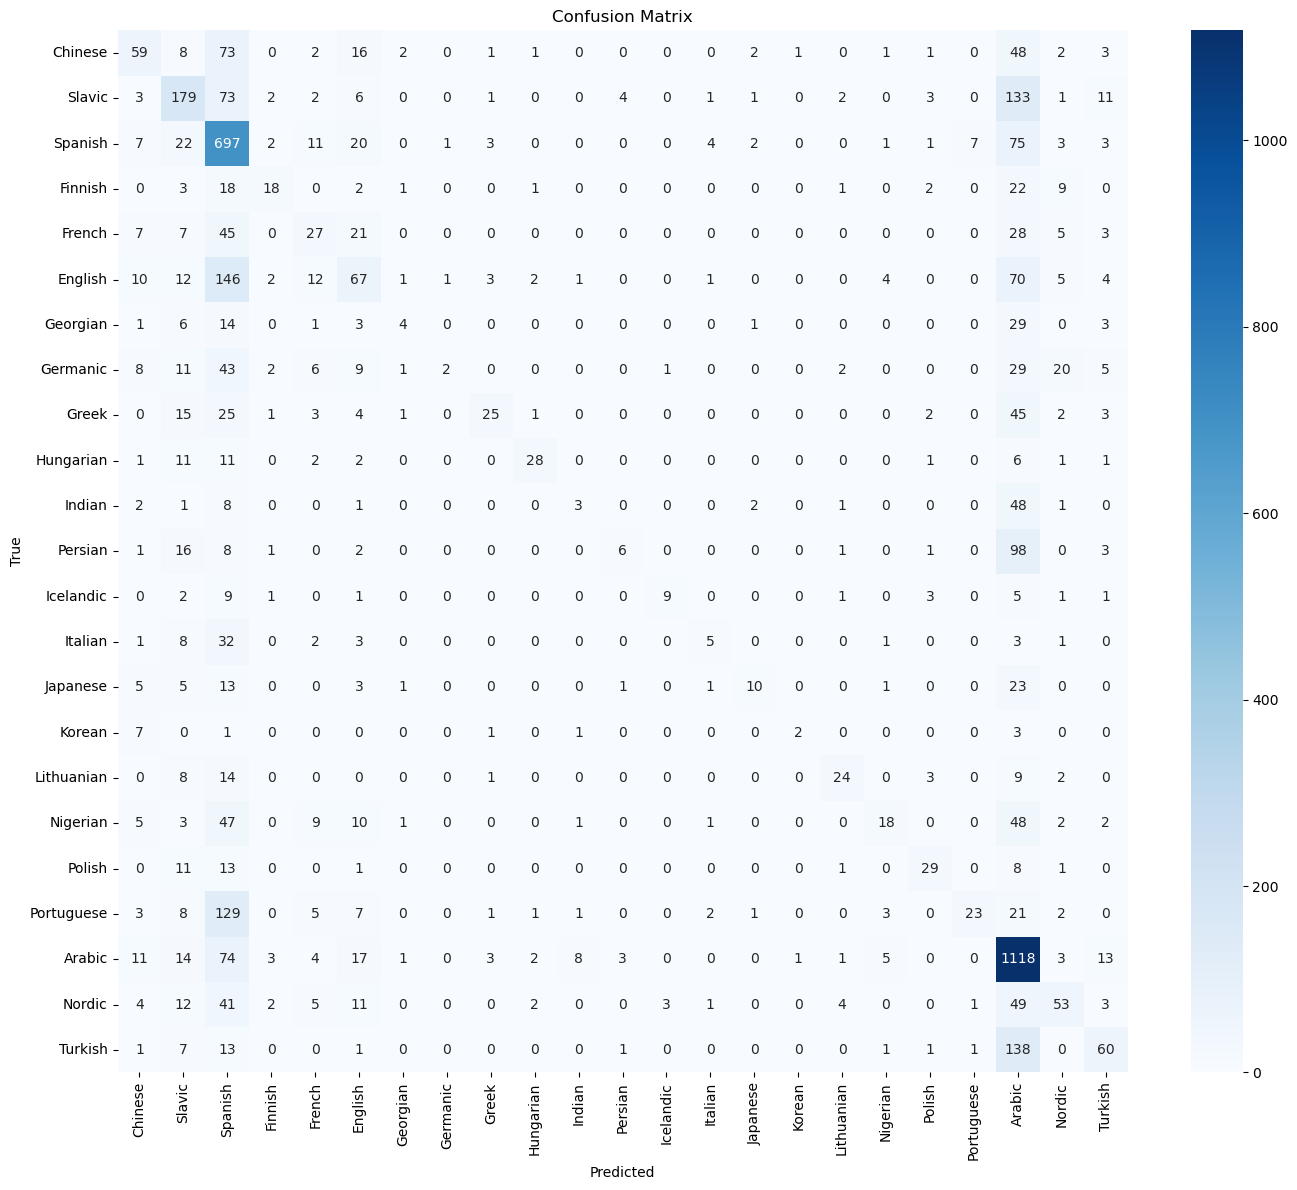

In [41]:
# Per-nationality evaluation (first name model)
eval_confusion(net_first, 5000, X_test, y_test)

In [42]:
# Confidence vs accuracy analysis (first name model)
data_ = dataloader(10000, X_test, y_test, replace=False)
buckets = {}
for name, nat, name_ohe, nat_idx in data_:
    output = infer(net_first, name)
    if output is None:
        continue
    topv, topi = output.topk(1)
    conf = math.exp(topv[0][0].item())
    bucket = round(conf, 1)
    correct = (topi[0][0].item() == nat_idx.item())
    buckets.setdefault(bucket, [0, 0])
    buckets[bucket][0] += correct
    buckets[bucket][1] += 1

print("Confidence | Accuracy | Count")
for b in sorted(buckets):
    acc = buckets[b][0] / buckets[b][1]
    print(f"     {b:.1f}    |  {acc:.2f}    | {buckets[b][1]}")

Confidence | Accuracy | Count
     0.1    |  0.14    | 131
     0.2    |  0.23    | 1556
     0.3    |  0.30    | 1731
     0.4    |  0.43    | 1550
     0.5    |  0.48    | 986
     0.6    |  0.55    | 937
     0.7    |  0.68    | 726
     0.8    |  0.77    | 1038
     0.9    |  0.82    | 775
     1.0    |  0.83    | 570


In [43]:
torch.save(net_first.state_dict(), 'rnn_firstname_nat.pth')
print("First name model saved to rnn_firstname_nat.pth")

First name model saved to rnn_firstname_nat.pth


In [44]:
# Load saved first name model (skip training cell above if already trained)
n_hidden = 256
net_first = GRU_net(n_letters, n_hidden, n_nationalities)
net_first.load_state_dict(torch.load('rnn_firstname_nat.pth', weights_only=True))
net_first.eval()
print("First name model loaded from rnn_firstname_nat.pth")

First name model loaded from rnn_firstname_nat.pth


In [45]:
print("--- Mohammed ---")
predict(net_first, "Mohammed")
print("\n--- Giovanni ---")
predict(net_first, "Giovanni")
print("\n--- Yuki ---")
predict(net_first, "Yuki")
print("\n--- Carlos ---")
predict(net_first, "Carlos")

--- Mohammed ---
Arabic (SA): 0.9195
English (GB): 0.0140
French (FR): 0.0126

--- Giovanni ---
Spanish (ES): 0.5272
Italian (IT): 0.2615
Portuguese (PT): 0.0628

--- Yuki ---
Japanese (JP): 0.7585
Chinese (CN): 0.0782
Spanish (ES): 0.0431

--- Carlos ---
Spanish (ES): 0.8387
Portuguese (PT): 0.0688
English (GB): 0.0428


[('ES', 0.8386864421101579),
 ('PT', 0.06875323079095165),
 ('GB', 0.04279826334058432)]

---
# Combined First + Last Name Prediction

In [46]:
print("--- Yuki Tanaka ---")
predict_full_name(net_first, net_last, "Yuki", "Tanaka")
print("\n--- John Smith ---")
predict_full_name(net_first, net_last, "John", "Smith")
print("\n--- Mohammed Ahmed ---")
predict_full_name(net_first, net_last, "Mohammed", "Ahmed")
print("\n--- Carlos Garcia ---")
predict_full_name(net_first, net_last, "Carlos", "Garcia")
print("\n--- Minjun Kim ---")
predict_full_name(net_first, net_last, "Minjun", "Kim")
print("\n--- Hans Mueller ---")
predict_full_name(net_first, net_last, "Hans", "Mueller")
print("\n--- Giovanni Rossi ---")
predict_full_name(net_first, net_last, "Giovanni", "Rossi")

--- Yuki Tanaka ---
Japanese (JP): 0.5321
Arabic (SA): 0.0592
Chinese (CN): 0.0415

--- John Smith ---
English (GB): 0.3376
Arabic (SA): 0.1010
Spanish (ES): 0.0934

--- Mohammed Ahmed ---
Arabic (SA): 0.8339
English (GB): 0.0214
Nigerian (NG): 0.0212

--- Carlos Garcia ---
Spanish (ES): 0.7654
English (GB): 0.0530
Portuguese (PT): 0.0437

--- Minjun Kim ---
Arabic (SA): 0.2482
Chinese (CN): 0.1469
Indian (IN): 0.0610

--- Hans Mueller ---
Arabic (SA): 0.1538
English (GB): 0.1225
Nordic (SE): 0.0943

--- Giovanni Rossi ---
Italian (IT): 0.2712
Spanish (ES): 0.1799
Portuguese (PT): 0.0656


[('IT', 0.2711840899991766),
 ('ES', 0.17989837967517575),
 ('PT', 0.06562555055065619)]